In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the signal file if not already in memory
signals_eb_df = pd.read_csv("quality_signals_eb/firm_year_quality_signals_eb.csv")

# Keep only rows with both quintiles available
cmp = signals_eb_df.dropna(subset=["q_m1", "q_m2"]).copy()

# Make sure they are integers
cmp["q_m1"] = cmp["q_m1"].astype(int)
cmp["q_m2"] = cmp["q_m2"].astype(int)

# ---------------------------------
# 1. Overall 5x5 transition matrix
# ---------------------------------
transition_counts = pd.crosstab(
    cmp["q_m1"],
    cmp["q_m2"],
    rownames=["M1 quintile"],
    colnames=["M2 quintile"]
)

print("Overall transition matrix: M1 vs M2")
display(transition_counts)


Overall transition matrix: M1 vs M2


M2 quintile,1,2,3,4,5
M1 quintile,,,,,
1,1060,324,67,0,0
2,384,954,120,0,0
3,7,175,1027,252,0
4,0,4,156,956,342
5,0,1,91,250,1122


In [8]:

# ---------------------------------
# 2. Row-normalized version (%)
# ---------------------------------
transition_pct = transition_counts.div(transition_counts.sum(axis=1), axis=0) * 100

print("Row-normalized transition matrix (%)")
display(transition_pct.round(2))


Row-normalized transition matrix (%)


M2 quintile,1,2,3,4,5
M1 quintile,,,,,
1,73.05,22.33,4.62,0.00,0.00
2,26.34,65.43,8.23,0.00,0.00
3,0.48,11.98,70.29,17.25,0.00
4,0.00,0.27,10.70,65.57,23.46
5,0.00,0.07,6.22,17.08,76.64


In [9]:

# ---------------------------------
# 3. Firms that changed quintile
# ---------------------------------
cmp["changed_quintile"] = cmp["q_m1"] != cmp["q_m2"]
cmp["moved_by"] = cmp["q_m2"] - cmp["q_m1"]
cmp["abs_move"] = cmp["moved_by"].abs()

n_total = len(cmp)
n_changed = cmp["changed_quintile"].sum()
share_changed = 100 * n_changed / n_total

print(f"Total firm-years: {n_total}")
print(f"Changed quintile: {n_changed} ({share_changed:.2f}%)")

print("\nDistribution of quintile moves:")
display(cmp["moved_by"].value_counts().sort_index())


Total firm-years: 7292
Changed quintile: 2173 (29.80%)

Distribution of quintile moves:


moved_by
-3       1
-2     102
-1     965
 0    5119
 1    1038
 2      67
Name: count, dtype: int64

In [10]:

# ---------------------------------
# 4. Same thing by formation year
# ---------------------------------
yearly_changes = (
    cmp.groupby("FormationYear")
    .agg(
        n_firms=("Ticker", "count"),
        n_changed=("changed_quintile", "sum"),
        avg_abs_move=("abs_move", "mean"),
    )
    .reset_index()
)

yearly_changes["share_changed_pct"] = 100 * yearly_changes["n_changed"] / yearly_changes["n_firms"]

print("\nYearly change summary:")
display(yearly_changes)



Yearly change summary:


,FormationYear,n_firms,n_changed,avg_abs_move,share_changed_pct
0,2010,307,72,0.247557,23.452769
1,2011,324,75,0.253086,23.148148
2,2012,339,64,0.200590,18.879056
3,2013,356,61,0.174157,17.134831
4,2014,375,75,0.218667,20.000000
5,2015,389,104,0.277635,26.735219
6,2016,420,102,0.257143,24.285714
7,2017,432,104,0.250000,24.074074
8,2018,463,103,0.233261,22.246220
9,2019,492,167,0.369919,33.943089


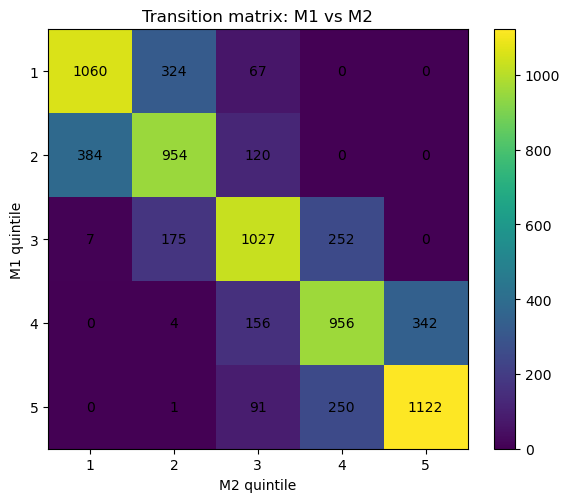

In [11]:

# ---------------------------------
# 5. Simple heatmap using matplotlib
# ---------------------------------
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(transition_counts.values)

ax.set_xticks(range(5))
ax.set_yticks(range(5))
ax.set_xticklabels([1, 2, 3, 4, 5])
ax.set_yticklabels([1, 2, 3, 4, 5])

ax.set_xlabel("M2 quintile")
ax.set_ylabel("M1 quintile")
ax.set_title("Transition matrix: M1 vs M2")

# Annotate cells
for i in range(transition_counts.shape[0]):
    for j in range(transition_counts.shape[1]):
        ax.text(j, i, transition_counts.iloc[i, j], ha="center", va="center")

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

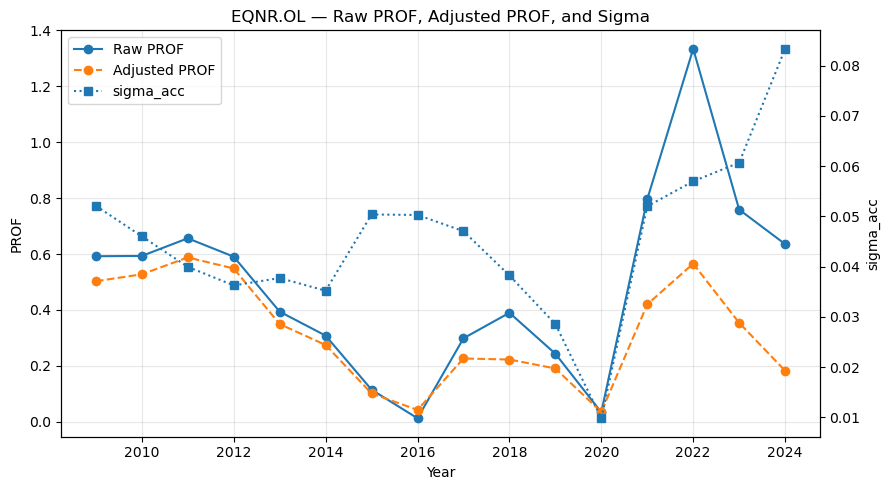

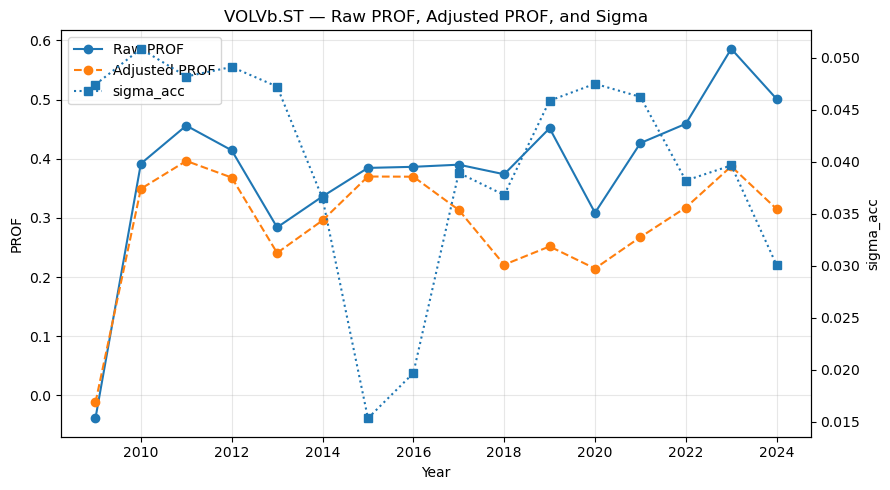

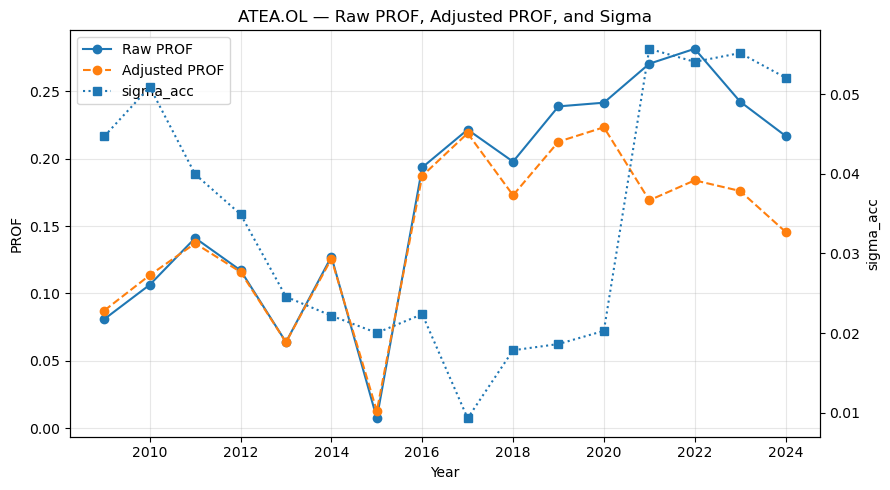

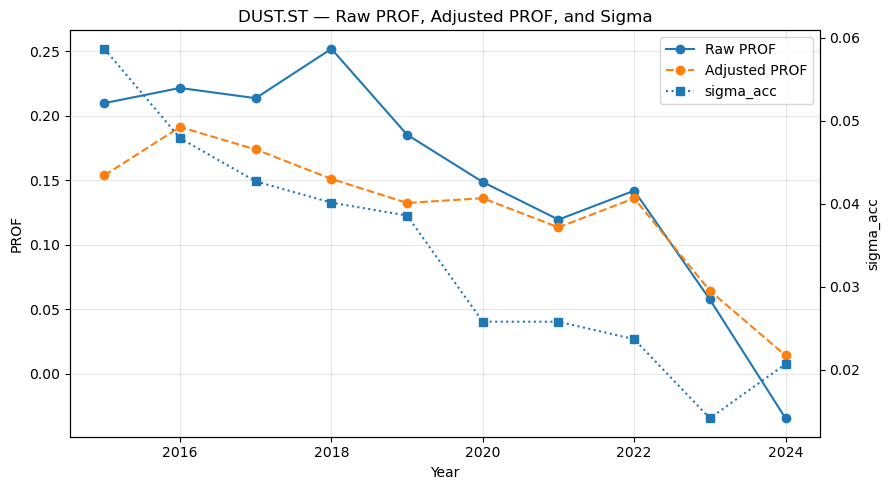

In [13]:
# Example: replace with the tickers you want
tickers_to_plot = ["EQNR.OL", "VOLVb.ST", "ATEA.OL", "DUST.ST"]

ADJUSTED_COL = "theta_post_mean"
SIGMA_COL = "sigma_acc"

plot_df = signals_eb_df.dropna(subset=["PROF", ADJUSTED_COL, SIGMA_COL, "Ticker", "Year"]).copy()
plot_df = plot_df.sort_values(["Ticker", "Year"])

for ticker in tickers_to_plot:
    sub = plot_df[plot_df["Ticker"] == ticker].copy().sort_values("Year")

    if sub.empty:
        print(f"No data for {ticker}")
        continue

    fig, ax1 = plt.subplots(figsize=(9, 5))

    ax1.plot(sub["Year"], sub["PROF"], marker="o", label="Raw PROF")
    ax1.plot(sub["Year"], sub[ADJUSTED_COL], marker="o", linestyle="--", label="Adjusted PROF")
    ax1.set_xlabel("Year")
    ax1.set_ylabel("PROF")
    ax1.set_title(f"{ticker} — Raw PROF, Adjusted PROF, and Sigma")
    ax1.grid(True, alpha=0.3)

    ax2 = ax1.twinx()
    ax2.plot(sub["Year"], sub[SIGMA_COL], marker="s", linestyle=":", label="sigma_acc")
    ax2.set_ylabel("sigma_acc")

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")

    plt.tight_layout()
    plt.show()

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

# ---------------------------------
# Load residual file if resid_df is not in memory
# ---------------------------------
if "resid_df" not in globals():
    resid_path = "acc_noise_ols_no_lead/firm_year_residuals_and_sigma_no_lead_avgat.csv"
    resid_df = pd.read_csv(resid_path)


Example firm-years used for posterior plots:


,Ticker,Year,FormationYear,theta_obs,theta_post_mean,theta_post_sd,sigma_raw,lambda_i
0,20202.OL,2021,2022,0.420081,0.415013,0.022351,0.006084,0.984547
1,AGFEb.CO,2009,2010,-0.835917,0.090974,0.304453,0.568253,0.034379
2,COREa.ST,2009,2010,0.103189,0.123260,0.304453,0.568253,0.034379
3,ENVIP.OL,2022,2023,-0.134981,0.085149,0.130309,0.126753,0.115504
4,HUMAN.ST,2021,2022,0.149486,0.148599,0.022351,0.006084,0.984547
5,NICA.ST,2019,2020,-3.868477,-0.176475,0.225131,0.176566,0.060451
6,STZEb.ST,2019,2020,-3.868477,-0.244456,0.223049,0.154249,0.077751
7,VEI.OL,2013,2014,0.242481,0.186033,0.168596,0.064818,0.686661


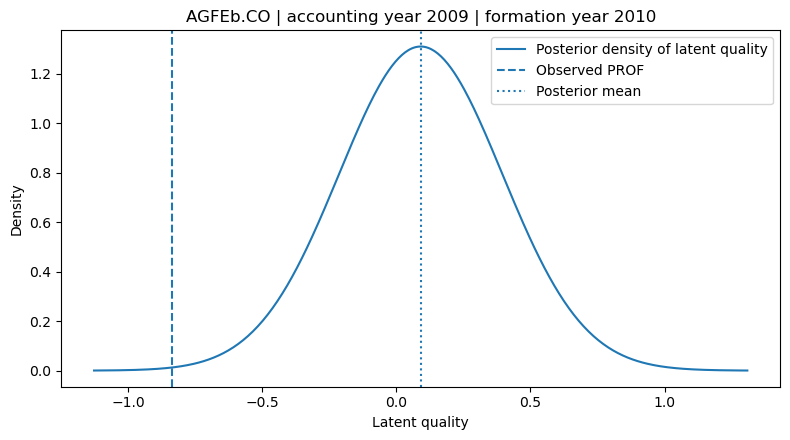

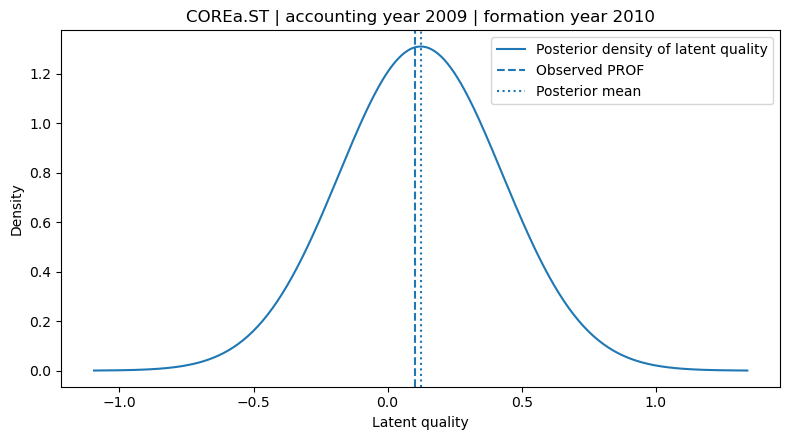

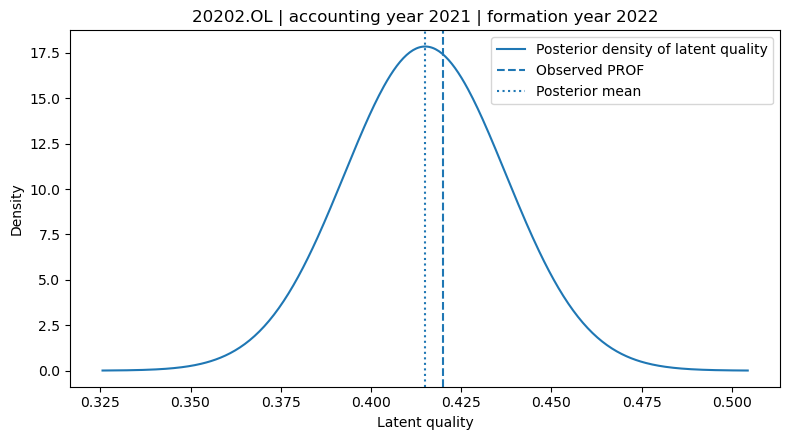

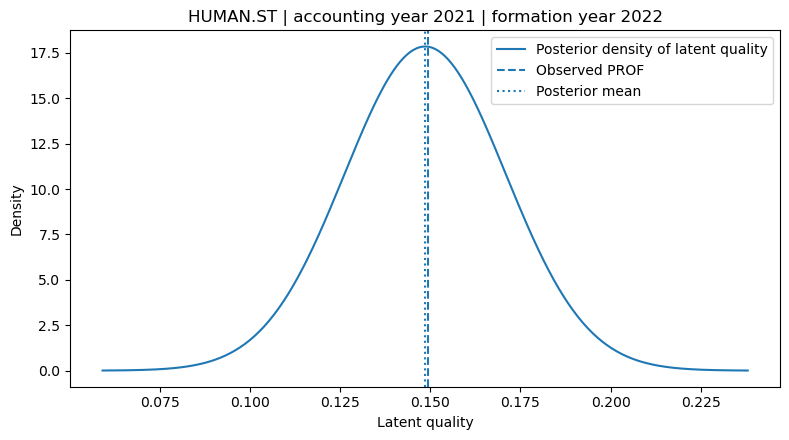

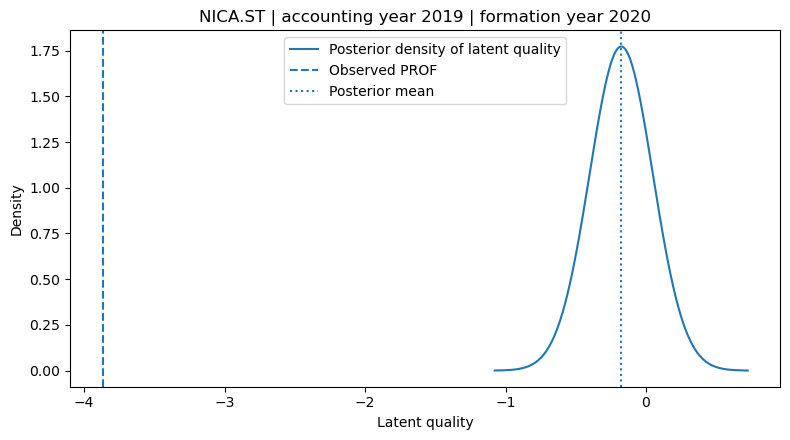

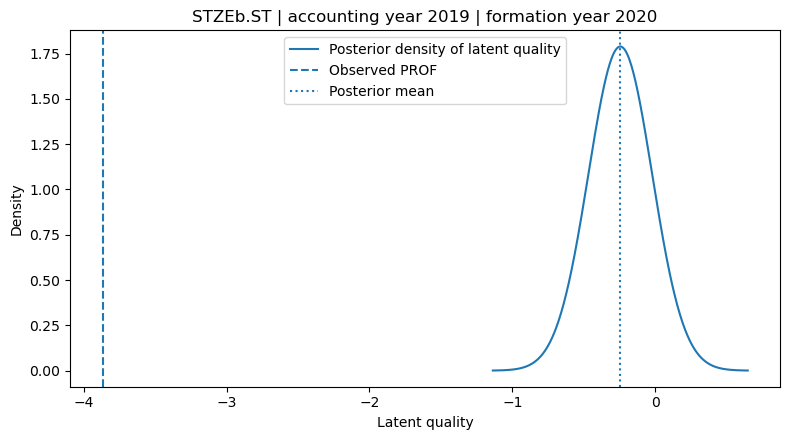

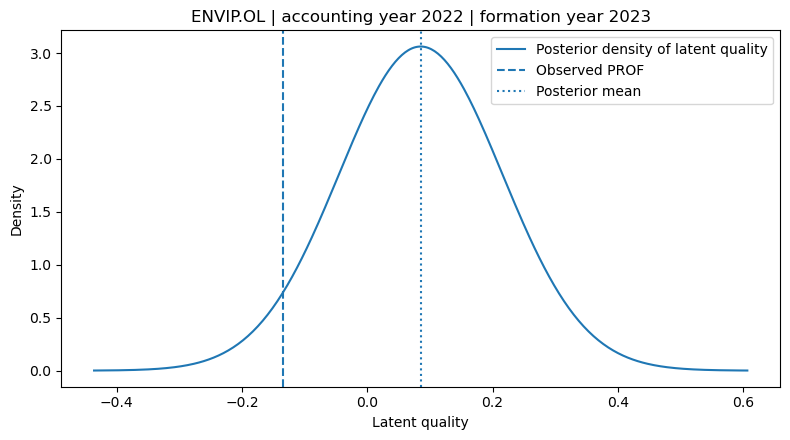

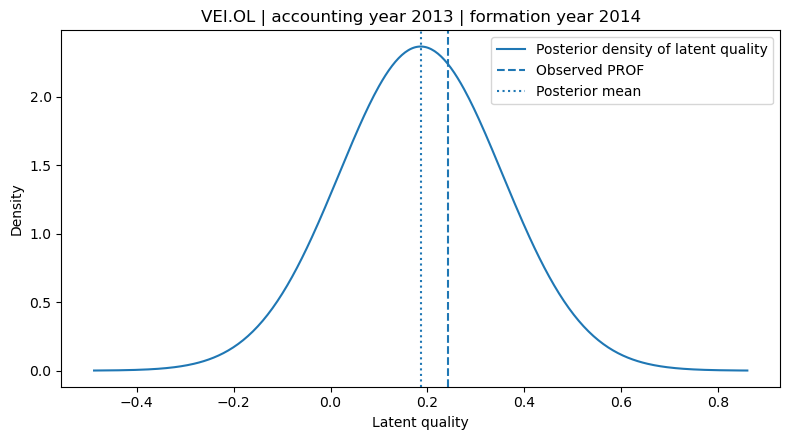

In [15]:

# ---------------------------------
# 1. Posterior distributions of latent quality
# ---------------------------------
# Pick a few interesting examples:
# - highest sigma
# - lowest sigma
# - biggest shrinkage gap
# - random examples

posterior_df = signals_eb_df.dropna(
    subset=["theta_post_mean", "theta_post_sd", "theta_obs", "sigma_raw", "Ticker", "Year"]
).copy()

posterior_df["shrink_gap"] = (posterior_df["theta_obs"] - posterior_df["theta_post_mean"]).abs()

examples = pd.concat([
    posterior_df.nlargest(2, "sigma_raw"),
    posterior_df.nsmallest(2, "sigma_raw"),
    posterior_df.nlargest(2, "shrink_gap"),
    posterior_df.sample(n=min(2, len(posterior_df)), random_state=42)
], ignore_index=True).drop_duplicates(subset=["Ticker", "Year"])

print("Example firm-years used for posterior plots:")
display(
    examples[["Ticker", "Year", "FormationYear", "theta_obs", "theta_post_mean", "theta_post_sd", "sigma_raw", "lambda_i"]]
    .sort_values(["Ticker", "Year"])
    .reset_index(drop=True)
)

for _, row in examples.iterrows():
    mu = row["theta_post_mean"]
    sd = row["theta_post_sd"]
    theta_obs = row["theta_obs"]

    if not np.isfinite(sd) or sd <= 0:
        continue

    x = np.linspace(mu - 4 * sd, mu + 4 * sd, 400)
    y = norm.pdf(x, loc=mu, scale=sd)

    plt.figure(figsize=(8, 4.5))
    plt.plot(x, y, label="Posterior density of latent quality")
    plt.axvline(theta_obs, linestyle="--", label="Observed PROF")
    plt.axvline(mu, linestyle=":", label="Posterior mean")
    plt.title(f"{row['Ticker']} | accounting year {int(row['Year'])} | formation year {int(row['FormationYear'])}")
    plt.xlabel("Latent quality")
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.show()


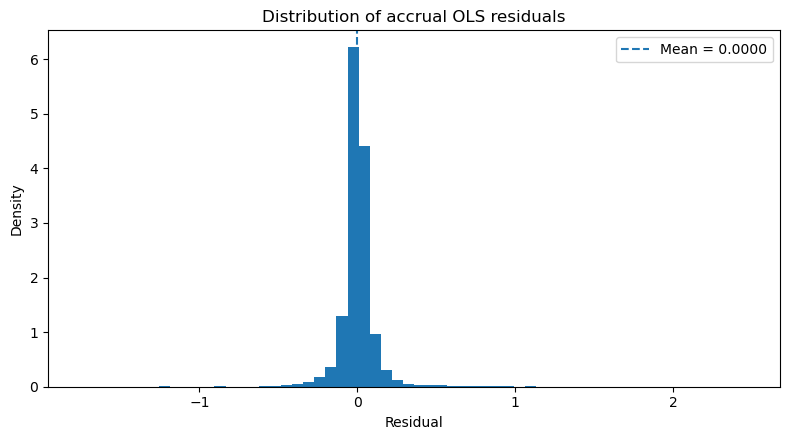

Residual summary:


count    9.275000e+03
mean     2.872814e-19
std      1.175091e-01
min     -1.746961e+00
25%     -3.340745e-02
50%     -8.902616e-04
75%      3.195713e-02
max      2.465196e+00
Name: dd_resid, dtype: float64

In [16]:

# ---------------------------------
# 2. Distribution of accrual OLS residuals
# ---------------------------------
residual_col = "dd_resid"

resid_plot = resid_df.copy()
resid_plot[residual_col] = pd.to_numeric(resid_plot[residual_col], errors="coerce")
resid_plot = resid_plot.dropna(subset=[residual_col])

plt.figure(figsize=(8, 4.5))
plt.hist(resid_plot[residual_col], bins=60, density=True)
plt.axvline(resid_plot[residual_col].mean(), linestyle="--", label=f"Mean = {resid_plot[residual_col].mean():.4f}")
plt.title("Distribution of accrual OLS residuals")
plt.xlabel("Residual")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

print("Residual summary:")
display(resid_plot[residual_col].describe())


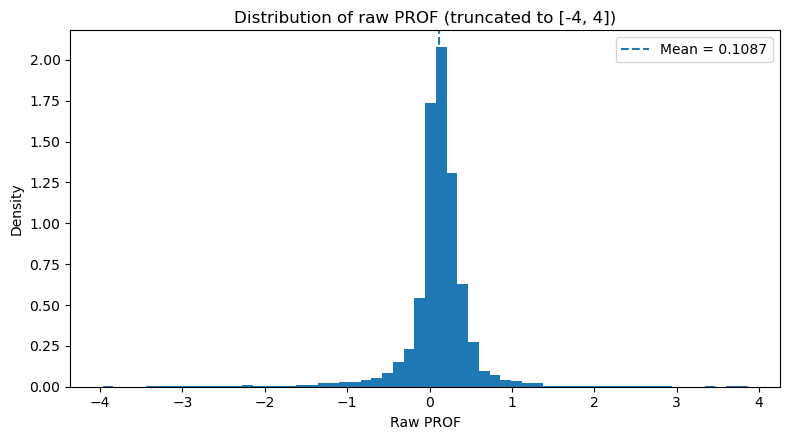

Raw PROF summary (full sample):


count    7292.000000
mean        0.048138
std         2.745071
min      -175.661479
25%         0.007288
50%         0.121126
75%         0.260997
max        34.507853
Name: PROF, dtype: float64

Raw PROF summary (truncated to [-4, 4]):


count    7239.000000
mean        0.108693
std         0.459352
min        -3.968409
25%         0.009641
50%         0.121623
75%         0.260404
max         3.860662
Name: PROF, dtype: float64

Observations kept after PROF truncation: 7239 / 7292


In [17]:

# ---------------------------------
# 3. Distribution of raw PROF, truncated to [-4, 4]
# ---------------------------------
prof_plot = signals_eb_df.copy()
prof_plot["PROF"] = pd.to_numeric(prof_plot["PROF"], errors="coerce")
prof_plot = prof_plot.dropna(subset=["PROF"]).copy()

prof_plot_trunc = prof_plot[(prof_plot["PROF"] >= -4) & (prof_plot["PROF"] <= 4)].copy()

plt.figure(figsize=(8, 4.5))
plt.hist(prof_plot_trunc["PROF"], bins=60, density=True)
plt.axvline(prof_plot_trunc["PROF"].mean(), linestyle="--", label=f"Mean = {prof_plot_trunc['PROF'].mean():.4f}")
plt.title("Distribution of raw PROF (truncated to [-4, 4])")
plt.xlabel("Raw PROF")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

print("Raw PROF summary (full sample):")
display(prof_plot["PROF"].describe())

print("Raw PROF summary (truncated to [-4, 4]):")
display(prof_plot_trunc["PROF"].describe())

print(f"Observations kept after PROF truncation: {len(prof_plot_trunc)} / {len(prof_plot)}")